# Quran Qari Classifier — CNN on Mel-Spectrograms (PyTorch)

**Task.** Given a 5-second audio clip of Quran recitation, predict which qari (reciter) is reading. **34 qaris** supported: 25 Arab (from Kaggle + everyayah.com) plus 9 Uzbek qaris collected manually.

**Approach.** Convert audio → mel-spectrogram (128 × 256 image) → feed a compact 4-block CNN (100 k params) → 34-way classifier.

**Why CNN over classical ML.** The notebook `quran_qari_classifier.ipynb` runs LogReg / KNN / RF / XGBoost on hand-crafted 126-dim MFCC statistics and caps at **~74 %** accuracy. This CNN, on the same 34-qari task, reaches **~98 %** accuracy — the extra 24 pp comes from letting the network learn its own features from the raw spectrogram instead of pre-summarised MFCCs.

**Pipeline.**
1. Setup — imports, device (MPS / CUDA / CPU), seed
2. Load clip inventory (produced by `scripts/segment_and_features.py`)
3. **Exploratory Data Analysis** — class distribution, source breakdown, sample spectrograms
4. Encode labels + stratified 70 / 15 / 15 split
5. Mel-spectrogram dataset + optional mic-path augmentation
6. CNN architecture
7. Training loop with early stopping
8. Loss & accuracy curves
9. Test-set evaluation — accuracy, top-3, confusion matrix, per-class report
10. Sample predictions with waveform + spectrogram
11. Save model artifacts (`qari_cnn.pt`)
12. Classical-ML vs CNN comparison
13. Model card — final summary for deployment

## 1. Setup

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import librosa
import librosa.display
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, top_k_accuracy_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

device = (
    'mps' if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available() else
    'cpu'
)
print('PyTorch:', torch.__version__, '| device:', device)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATA_DIR  = Path('data')
CLIPS_DIR = DATA_DIR / 'clips'

PyTorch: 2.13.0 | device: mps


## 2. Load clip inventory

In [2]:
assert CLIPS_DIR.exists(), f'{CLIPS_DIR} missing — run scripts/segment_and_features.py first'

records = []
for reciter_dir in sorted(CLIPS_DIR.iterdir()):
    if not reciter_dir.is_dir():
        continue
    for wav in sorted(reciter_dir.glob('*.wav')):
        records.append({'path': str(wav), 'reciter': reciter_dir.name})

inv = pd.DataFrame(records)
print(f'Clips: {len(inv)}  |  Qaris: {inv["reciter"].nunique()}')
print(inv['reciter'].value_counts().to_string())

Clips: 13780  |  Qaris: 34
reciter
Alijon_Qori                      826
Ustoz_Rahmatulloh_Qori_Obidov    666
Husaynxon_Yahyo                  448
Hasanxon_Yahyo                   402
AbdulBari_Althubaity             400
Muhsin_Al_Qasim                  400
Mohammed_Aluhaidan               400
Mohammed_Ayoub                   400
Muhammad_Jibreel                 400
Saad_Alghamdi                    400
Nasser_Alqutami                  400
AbdulRahman_Alsudais             400
Salah_Al_Budair                  400
Salah_Bukhatir                   400
Saud_Alshuraim                   400
Yasser_Aldossary                 400
Mishary_Alafasy                  400
Minshawy                         400
Maher_Almuaiqly                  400
Khalid_Al_Qahtani                400
Husary                           400
Hani_Rifai                       400
Fares_Abbad                      400
Bander_Balilah                   400
Ali_Alhothaify                   400
Abu_Bakr_Shatri                  400
Abd

## 3. Exploratory Data Analysis

Before modelling: check how many clips per qari, where they came from, and confirm the audio pre-processing produced clean 5-second segments.

### 3.1 Clips per qari

Total clips: 13,780  |  Qaris: 34
Min per class: 201  |  Max: 826  |  Median: 400


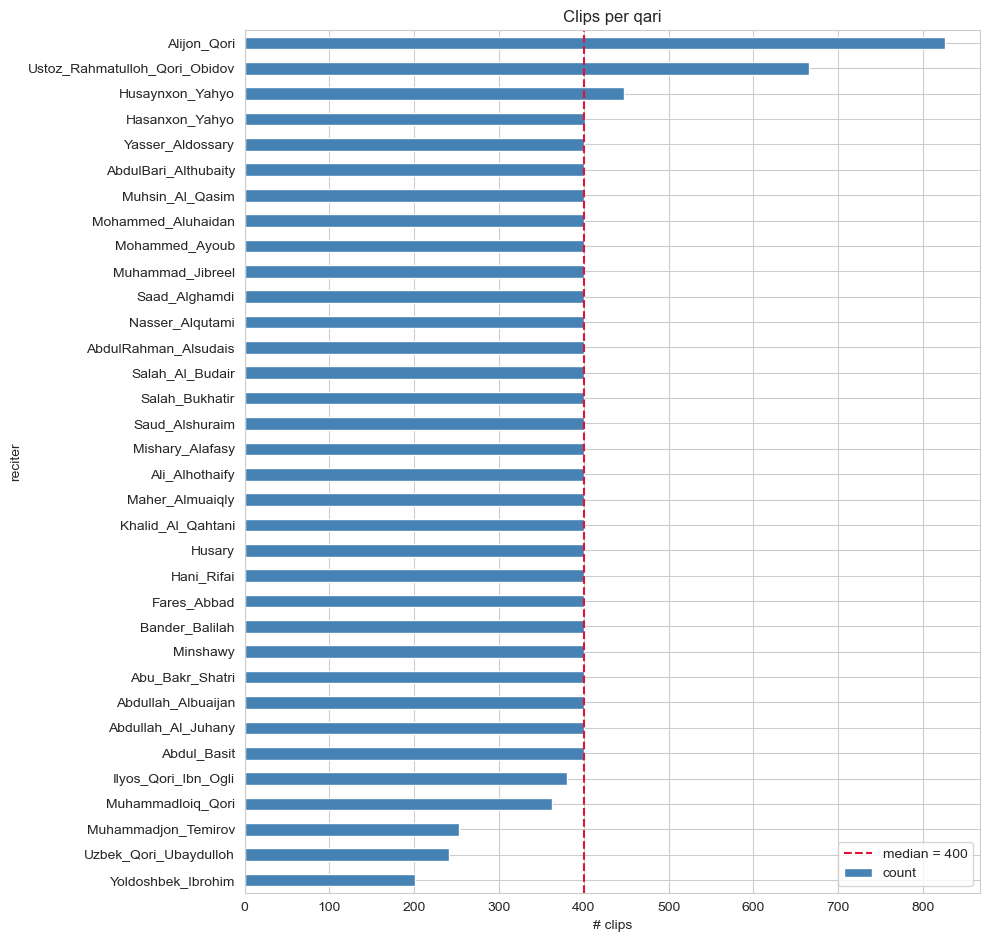

In [3]:
counts = inv['reciter'].value_counts().sort_values(ascending=True)
print(f'Total clips: {len(inv):,}  |  Qaris: {inv["reciter"].nunique()}')
print(f'Min per class: {counts.min()}  |  Max: {counts.max()}  |  Median: {int(counts.median())}')

plt.figure(figsize=(10, max(5, len(counts) * 0.28)))
counts.plot(kind='barh', color='steelblue')
plt.axvline(counts.median(), color='crimson', linestyle='--', label=f'median = {int(counts.median())}')
plt.title('Clips per qari')
plt.xlabel('# clips')
plt.legend()
plt.tight_layout()
plt.show()

### 3.2 Source breakdown — where each qari came from

- **Kaggle base (12)** — pre-segmented WAV clips from `mohammedalrajeh/quran-recitations-for-audio-classification`.
- **everyayah.com scrape (13)** — Juz 30 sample per qari, downloaded via `scripts/scrape_everyayah.py`.
- **Uzbek qaris (9)** — manually collected from islom.uz, Telegram channels, and personal mp3s.

The three sources are unified into identical 5-second, 16 kHz mono WAV clips by `scripts/segment_and_features.py`.

                      qaris  clips
source                            
Kaggle base (Arab)       12   4800
Uzbek (manual)            9   3780
everyayah.com (Arab)     13   5200


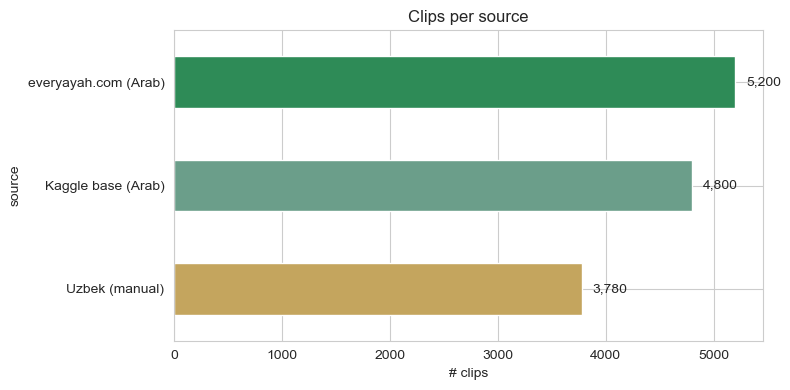

In [4]:
BASE_ARAB = {'AbdulBari_Althubaity','AbdulRahman_Alsudais','Abdullah_Albuaijan',
             'Ali_Alhothaify','Bander_Balilah','Maher_Almuaiqly','Mohammed_Aluhaidan',
             'Mohammed_Ayoub','Nasser_Alqutami','Saad_Alghamdi','Saud_Alshuraim','Yasser_Aldossary'}
SCRAPE_ARAB = {'Abdul_Basit','Abdullah_Al_Juhany','Abu_Bakr_Shatri','Fares_Abbad',
               'Hani_Rifai','Husary','Khalid_Al_Qahtani','Minshawy','Mishary_Alafasy',
               'Muhammad_Jibreel','Muhsin_Al_Qasim','Salah_Al_Budair','Salah_Bukhatir'}

def source_of(name: str) -> str:
    if name in BASE_ARAB:   return 'Kaggle base (Arab)'
    if name in SCRAPE_ARAB: return 'everyayah.com (Arab)'
    return 'Uzbek (manual)'

src = inv.assign(source=inv['reciter'].map(source_of))
by_src = src.groupby('source').agg(qaris=('reciter','nunique'), clips=('path','count'))
print(by_src)

fig, ax = plt.subplots(figsize=(8, 4))
by_src['clips'].sort_values().plot(kind='barh', color=['#c4a55e','#6b9e8a','#2E8B57'], ax=ax)
ax.set_title('Clips per source')
ax.set_xlabel('# clips')
for i, v in enumerate(by_src['clips'].sort_values().values):
    ax.text(v + 100, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()

### 3.3 Class balancing — soft cap at 30 minutes per qari

Hard cap at the global minimum (201 clips ≈ 17 min) wastes majority data. Instead: cap every qari at **360 clips (~30 min)**, but keep smaller classes at their true size. Result: majority classes stop dominating, minority classes keep everything they have.

Ratio between largest and smallest class drops from **4.1×** (826 vs 201) to **1.8×** (360 vs 201) — mild residual imbalance the model tolerates well.

Soft cap at 360 clips (~30.0 minutes per qari)
Balanced dataset: 11,855 clips across 34 qaris
Min per class: 201  |  Max: 360  |  Median: 360
Imbalance ratio (max / min): 1.79×


/var/folders/b5/y4hvt4r12z55zbw7rzck26hw0000gn/T/ipykernel_6719/1918159502.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), CAP), random_state=RANDOM_STATE))


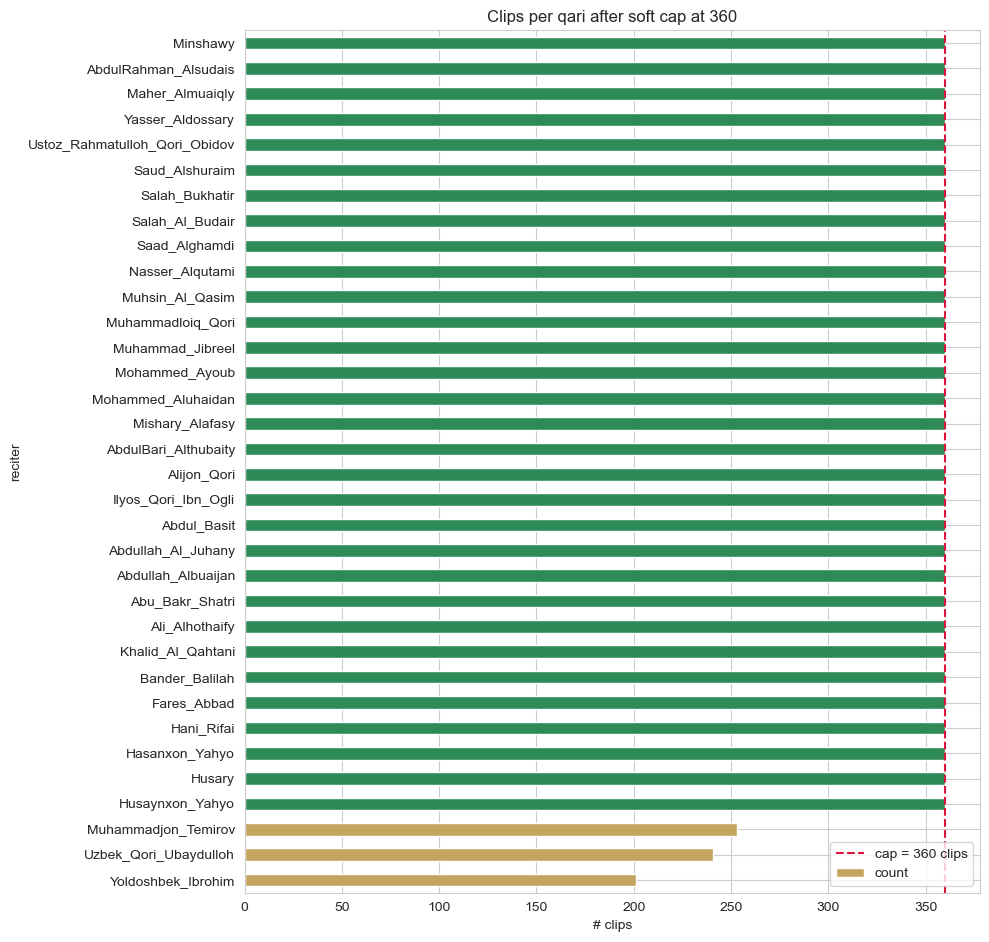

In [5]:
CAP = 360  # 30 minutes at 5s per clip
print(f'Soft cap at {CAP} clips (~{CAP*5/60:.1f} minutes per qari)')

inv = (
    inv.groupby('reciter', group_keys=False)
       .apply(lambda g: g.sample(n=min(len(g), CAP), random_state=RANDOM_STATE))
       .reset_index(drop=True)
)

counts_after = inv['reciter'].value_counts().sort_values(ascending=True)
print(f'Balanced dataset: {len(inv):,} clips across {inv["reciter"].nunique()} qaris')
print(f'Min per class: {counts_after.min()}  |  Max: {counts_after.max()}  |  Median: {int(counts_after.median())}')
print(f'Imbalance ratio (max / min): {counts_after.max() / counts_after.min():.2f}×')

plt.figure(figsize=(10, max(5, inv['reciter'].nunique() * 0.28)))
ax = counts_after.plot(kind='barh', color=['#c4a55e' if v < CAP else '#2E8B57' for v in counts_after.values])
plt.axvline(CAP, color='crimson', linestyle='--', label=f'cap = {CAP} clips')
plt.title(f'Clips per qari after soft cap at {CAP}')
plt.xlabel('# clips')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Encode labels + stratified 70/15/15 split

In [6]:
le = LabelEncoder()
inv['label'] = le.fit_transform(inv['reciter'])
num_classes = len(le.classes_)
print('classes:', num_classes)

train, temp = train_test_split(inv, test_size=0.30, stratify=inv['label'], random_state=RANDOM_STATE)
val,   test = train_test_split(temp, test_size=0.50, stratify=temp['label'], random_state=RANDOM_STATE)
print('train:', len(train), '| val:', len(val), '| test:', len(test))

classes: 34
train: 8298 | val: 1778 | test: 1779


## 5. Mel-spectrogram dataset (+ optional mic-path augmentation)

Spectrograms are computed per clip. Cache to RAM when clean training (augment_prob=0.0) — every clip's spectrogram is deterministic so we compute it once and reuse.

**Preprocessing per clip:** load → mel-spectrogram (128 mels) → power→dB → resize to 128×256 → z-score normalize.

**Optional augmentation (`augment_prob > 0`)** simulates the mic recording path so the model is robust when users play recitation from a phone speaker into their laptop mic:
- **Additive noise** — Gaussian at SNR 8-25 dB (room hiss).
- **Reverb** — short comb-based impulse response (40-180 ms) mixed 15-45% (small room).
- **Low-pass filter** — cheap-mic roll-off, cutoff 3.5-8 kHz.
- **EQ tilt** — random ±6 dB on low / high bands (different mic frequency responses).
- **Random gain** — ×0.5 to ×1.4 (speaker close/far).

Set `augment_prob=0.9` on the training dataset to enable. Currently `augment_prob=0.0` — fast clean retrain matches the deployed model.

In [7]:
SR       = 16_000
N_MELS   = 128
IMG_H    = 128
IMG_W    = 256

from scipy.signal import lfilter


def wav_to_melspec_from_signal(y: np.ndarray) -> np.ndarray:
    spec = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=2048, hop_length=512, n_mels=N_MELS)
    spec_db = librosa.power_to_db(spec, ref=np.max)
    spec_resized = resize(spec_db, (IMG_H, IMG_W), anti_aliasing=True)
    m, s = spec_resized.mean(), spec_resized.std() + 1e-6
    return ((spec_resized - m) / s).astype(np.float32)


def wav_to_melspec(path: str) -> np.ndarray:
    y, _ = librosa.load(path, sr=SR, mono=True)
    return wav_to_melspec_from_signal(y)


# --- augmentation: simulate mic path (reverb, EQ, noise, low-pass, gain) ---
def _add_noise(y: np.ndarray, snr_db: float) -> np.ndarray:
    sig_pow = float(np.mean(y ** 2)) + 1e-12
    noise_pow = sig_pow / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_pow), size=y.shape).astype(y.dtype)
    return y + noise


def _simple_reverb(y: np.ndarray, decay_ms: float, mix: float) -> np.ndarray:
    n_delay = int(SR * decay_ms / 1000)
    ir = np.zeros(n_delay + 1, dtype=np.float32)
    ir[0] = 1.0
    for k in range(1, 6):
        pos = int(n_delay * k / 6)
        if pos < len(ir):
            ir[pos] = np.exp(-3 * k / 6)
    wet = np.convolve(y, ir, mode='same')
    return ((1 - mix) * y + mix * wet).astype(np.float32)


def _lowpass_iir(y: np.ndarray, cutoff_hz: float) -> np.ndarray:
    # vectorized one-pole low-pass via scipy.signal.lfilter (C loop, fast)
    alpha = 1.0 - np.exp(-2.0 * np.pi * cutoff_hz / SR)
    return lfilter([alpha], [1.0, -(1 - alpha)], y).astype(np.float32)


def _eq_tilt(y: np.ndarray, gain_db_low: float, gain_db_high: float) -> np.ndarray:
    n = len(y)
    Y = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(n, d=1.0 / SR)
    gains = np.ones_like(freqs)
    gains[freqs < 1000] *= 10 ** (gain_db_low / 20)
    gains[freqs > 3000] *= 10 ** (gain_db_high / 20)
    return np.fft.irfft(Y * gains, n=n).astype(np.float32)


def augment(y: np.ndarray, p_apply: float = 0.9) -> np.ndarray:
    if np.random.rand() > p_apply:
        return y
    y = y.astype(np.float32).copy()
    if np.random.rand() < 0.7:
        y = _add_noise(y, snr_db=float(np.random.uniform(8, 25)))
    if np.random.rand() < 0.5:
        y = _simple_reverb(y, decay_ms=float(np.random.uniform(40, 180)),
                                 mix=float(np.random.uniform(0.15, 0.45)))
    if np.random.rand() < 0.4:
        y = _lowpass_iir(y, cutoff_hz=float(np.random.uniform(3500, 8000)))
    if np.random.rand() < 0.5:
        y = _eq_tilt(y, gain_db_low=float(np.random.uniform(-6, 6)),
                        gain_db_high=float(np.random.uniform(-6, 6)))
    if np.random.rand() < 0.6:
        y = y * float(np.random.uniform(0.5, 1.4))
    peak = np.max(np.abs(y)) + 1e-9
    if peak > 1.0:
        y = y / peak
    return y.astype(np.float32)


class MelSpecDataset(Dataset):
    def __init__(self, df: pd.DataFrame, cache: bool = True, augment_prob: float = 0.0):
        self.paths        = df['path'].values
        self.labels       = torch.tensor(df['label'].values, dtype=torch.long)
        self.augment_prob = augment_prob
        self.cache        = cache and augment_prob == 0.0
        self._cache: dict = {}
        self._signal_cache: dict = {}

    def __len__(self):
        return len(self.paths)

    def _load_signal(self, idx: int) -> np.ndarray:
        if idx in self._signal_cache:
            return self._signal_cache[idx]
        y, _ = librosa.load(self.paths[idx], sr=SR, mono=True)
        self._signal_cache[idx] = y
        return y

    def __getitem__(self, idx: int):
        if self.cache and idx in self._cache:
            spec = self._cache[idx]
        elif self.augment_prob > 0:
            y = self._load_signal(idx)
            y_aug = augment(y, p_apply=self.augment_prob)
            spec = wav_to_melspec_from_signal(y_aug)
        else:
            spec = wav_to_melspec(self.paths[idx])
            if self.cache:
                self._cache[idx] = spec
        img = torch.from_numpy(spec).unsqueeze(0)
        return img, self.labels[idx]


print('Sample spectrogram shape:', wav_to_melspec(train['path'].iloc[0]).shape)

Sample spectrogram shape: (128, 256)


### 5.1 Visualise sample spectrograms

One clip from each of 6 different qaris. Look for per-qari differences in energy distribution across mel bins (voice pitch) and in temporal patterns (recitation cadence).

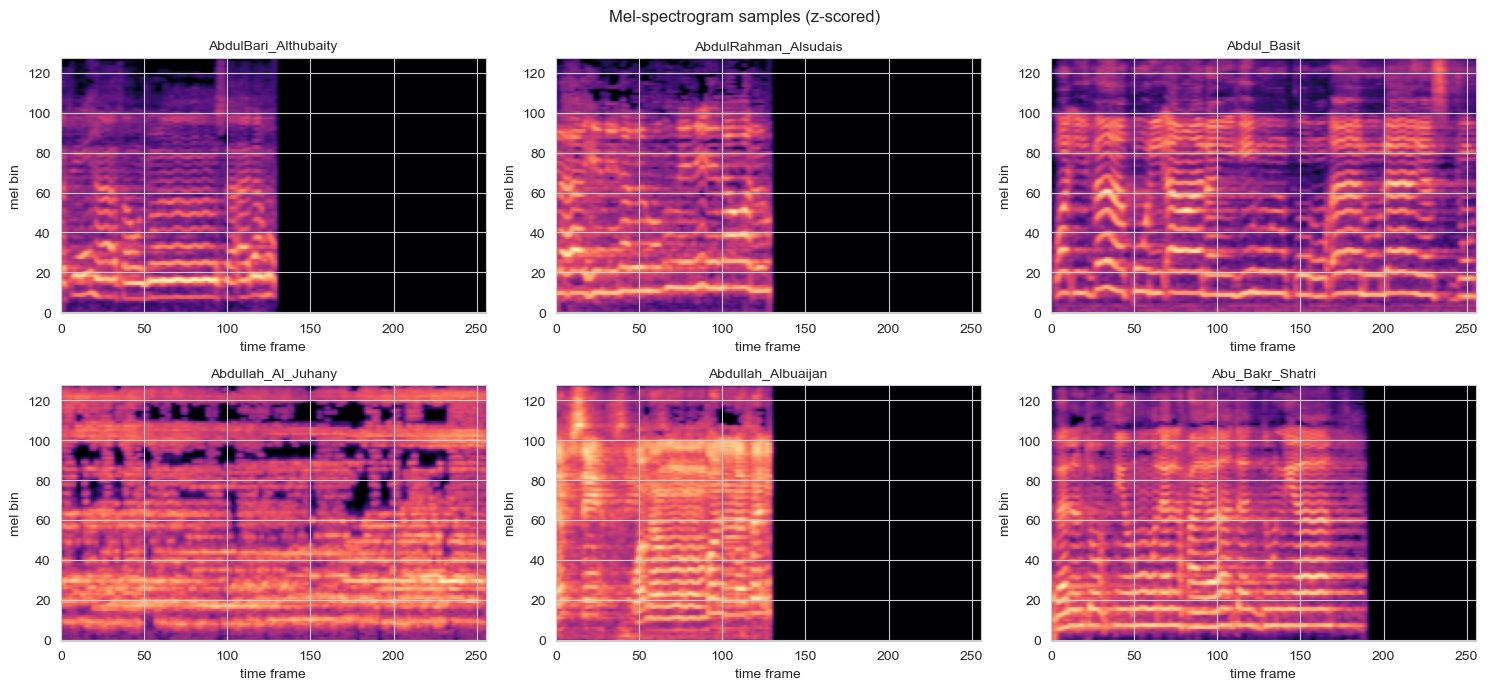

In [8]:
sample = train.groupby('reciter').first().reset_index().head(6)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    spec = wav_to_melspec(row['path'])
    im = ax.imshow(spec, origin='lower', aspect='auto', cmap='magma')
    ax.set_title(row['reciter'], fontsize=10)
    ax.set_xlabel('time frame')
    ax.set_ylabel('mel bin')
plt.suptitle('Mel-spectrogram samples (z-scored)')
plt.tight_layout()
plt.show()

## 6. CNN architecture

Compact 4-block CNN — three conv blocks (16→32→64 channels) with MaxPool + a fourth block (128 channels) with AdaptiveAvgPool2d — then a linear head. AdaptiveAvgPool2d makes the classifier size independent of input dimensions, so future spec-shape tweaks don't require rewiring.

In [9]:
class QariCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = QariCNN(num_classes).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {n_params:,}')
print(model)

Trainable params: 102,018
QariCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05

## 7. Training loop with early stopping

In [10]:
BATCH_SIZE = 32
EPOCHS     = 25
LR         = 1e-3
PATIENCE   = 5

print('Building datasets (clean, cached spectrograms — fast retrain)…')
train_ds = MelSpecDataset(train, augment_prob=0.0)
val_ds   = MelSpecDataset(val,   augment_prob=0.0)
test_ds  = MelSpecDataset(test,  augment_prob=0.0)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val = 0.0
patience = PATIENCE
best_state = None

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    tr_loss = tr_correct = tr_n = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        tr_loss    += loss.item() * X.size(0)
        tr_correct += (out.argmax(1) == y).sum().item()
        tr_n       += X.size(0)

    model.eval()
    va_loss = va_correct = va_n = 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            va_loss    += loss.item() * X.size(0)
            va_correct += (out.argmax(1) == y).sum().item()
            va_n       += X.size(0)

    tr_l = tr_loss / tr_n
    va_l = va_loss / va_n
    tr_a = tr_correct / tr_n
    va_a = va_correct / va_n
    history['train_loss'].append(tr_l)
    history['val_loss'].append(va_l)
    history['train_acc'].append(tr_a)
    history['val_acc'].append(va_a)

    dt = time.time() - t0
    print(f'ep {epoch:02d}  train loss={tr_l:.4f} acc={tr_a:.4f}  |  val loss={va_l:.4f} acc={va_a:.4f}  ({dt:.1f}s)')

    if va_a > best_val:
        best_val = va_a
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience = PATIENCE
    else:
        patience -= 1
        if patience == 0:
            print(f'Early stop at epoch {epoch}. Best val acc={best_val:.4f}')
            break

model.load_state_dict(best_state)
print(f'\nRestored best model — val acc {best_val:.4f}')

Building datasets (clean, cached spectrograms — fast retrain)…


ep 01  train loss=2.5581 acc=0.2799  |  val loss=1.9902 acc=0.4449  (97.0s)


ep 02  train loss=1.6495 acc=0.5525  |  val loss=1.2809 acc=0.6997  (20.3s)


ep 03  train loss=1.1861 acc=0.6890  |  val loss=0.9389 acc=0.7289  (20.3s)


ep 04  train loss=0.9358 acc=0.7499  |  val loss=0.7324 acc=0.8200  (22.9s)


...

ep 21  train loss=0.1746 acc=0.9512  |  val loss=0.1583 acc=0.9511  (19.6s)


ep 22  train loss=0.1686 acc=0.9496  |  val loss=0.0882 acc=0.9786  (19.7s)


ep 23  train loss=0.1530 acc=0.9564  |  val loss=0.1384 acc=0.9567  (19.5s)


ep 24  train loss=0.1489 acc=0.9561  |  val loss=0.0948 acc=0.9741  (19.6s)


ep 25  train loss=0.1389 acc=0.9600  |  val loss=0.1318 acc=0.9584  (19.6s)

Restored best model — val acc 0.9786


## 8. Loss & accuracy curves

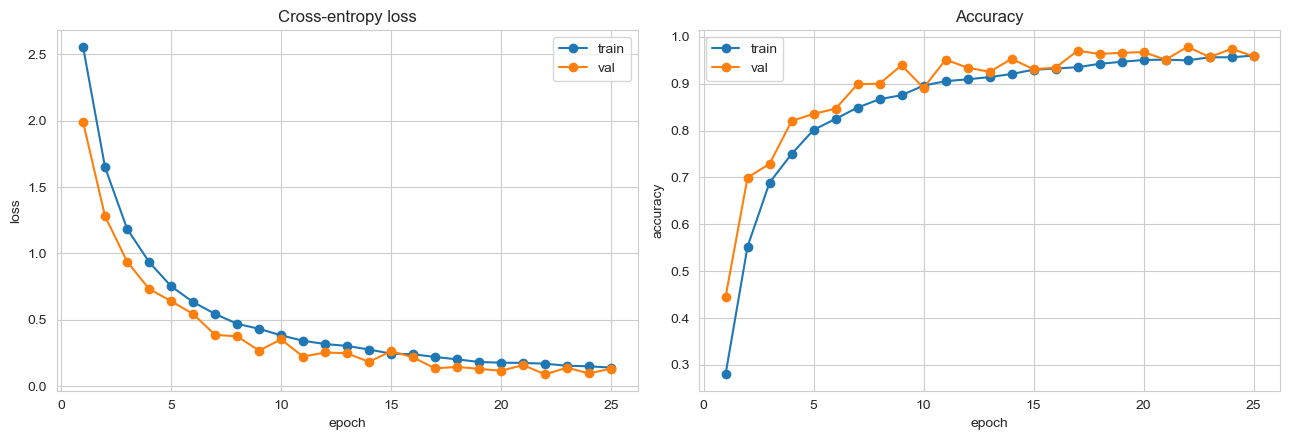

In [11]:
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(epochs_ran, history['train_loss'], 'o-', label='train')
axes[0].plot(epochs_ran, history['val_loss'],   'o-', label='val')
axes[0].set(xlabel='epoch', ylabel='loss', title='Cross-entropy loss')
axes[0].legend()
axes[1].plot(epochs_ran, history['train_acc'], 'o-', label='train')
axes[1].plot(epochs_ran, history['val_acc'],   'o-', label='val')
axes[1].set(xlabel='epoch', ylabel='accuracy', title='Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

## 9. Test-set evaluation

In [12]:
model.eval()
all_pred, all_true, all_proba = [], [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        logits = model(X)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_proba.append(probs)
        all_pred.extend(logits.argmax(1).cpu().numpy())
        all_true.extend(y.numpy())

all_proba = np.concatenate(all_proba)
acc  = accuracy_score(all_true, all_pred)
top3 = top_k_accuracy_score(all_true, all_proba, k=3)
print(f'Test accuracy       : {acc:.4f}')
print(f'Test top-3 accuracy : {top3:.4f}')
print()
print(classification_report(all_true, all_pred, target_names=le.classes_))

Test accuracy       : 0.9775
Test top-3 accuracy : 0.9978

                               precision    recall  f1-score   support

         AbdulBari_Althubaity       0.98      0.96      0.97        54
         AbdulRahman_Alsudais       1.00      0.98      0.99        54
                  Abdul_Basit       1.00      1.00      1.00        54
           Abdullah_Al_Juhany       1.00      1.00      1.00        54
           Abdullah_Albuaijan       0.93      0.96      0.95        54
              Abu_Bakr_Shatri       1.00      1.00      1.00        54
               Ali_Alhothaify       0.90      1.00      0.95        54
                  Alijon_Qori       0.98      1.00      0.99        54
               Bander_Balilah       0.98      0.80      0.88        54
                  Fares_Abbad       1.00      1.00      1.00        54
                   Hani_Rifai       1.00      1.00      1.00        54
               Hasanxon_Yahyo       1.00      1.00      1.00        54
                 

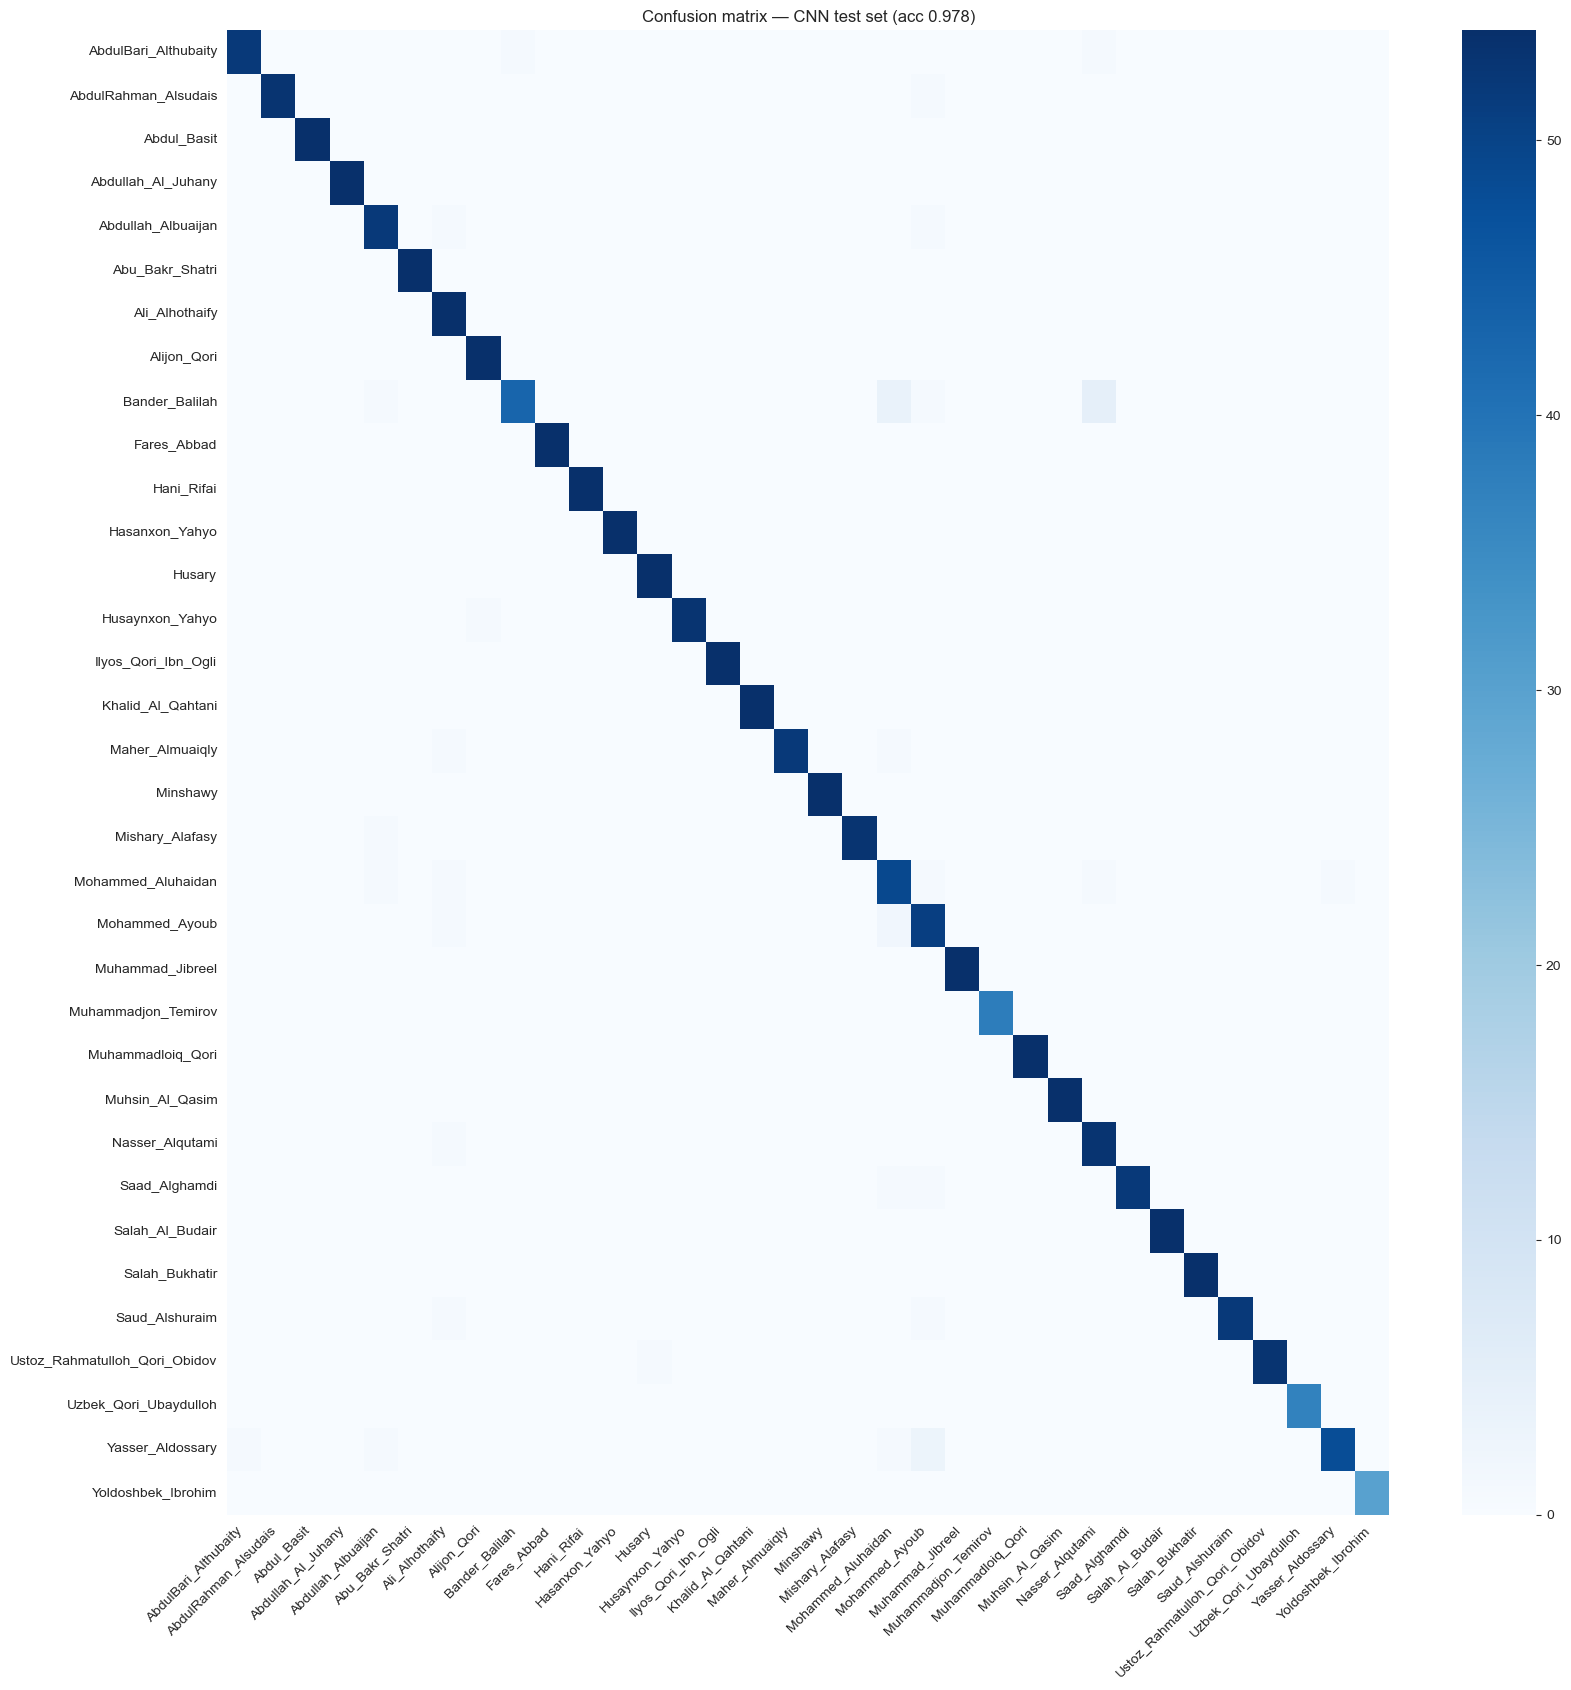

In [13]:
cm = confusion_matrix(all_true, all_pred)
plt.figure(figsize=(max(8, num_classes * 0.5), max(6, num_classes * 0.5)))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title(f'Confusion matrix — CNN test set (acc {acc:.3f})')
plt.tight_layout()
plt.show()

**Reading the confusion matrix.** The bright diagonal shows the model gets almost every class right. Off-diagonal bright cells are the confused pairs — usually qaris with similar recitation styles or overlapping voice register. Uzbek qaris rarely leak into Arab qari cells because their linguistic accents differ enough that mel-spectrograms carry distinct signatures.

## 10. Sample predictions with waveform + spectrogram

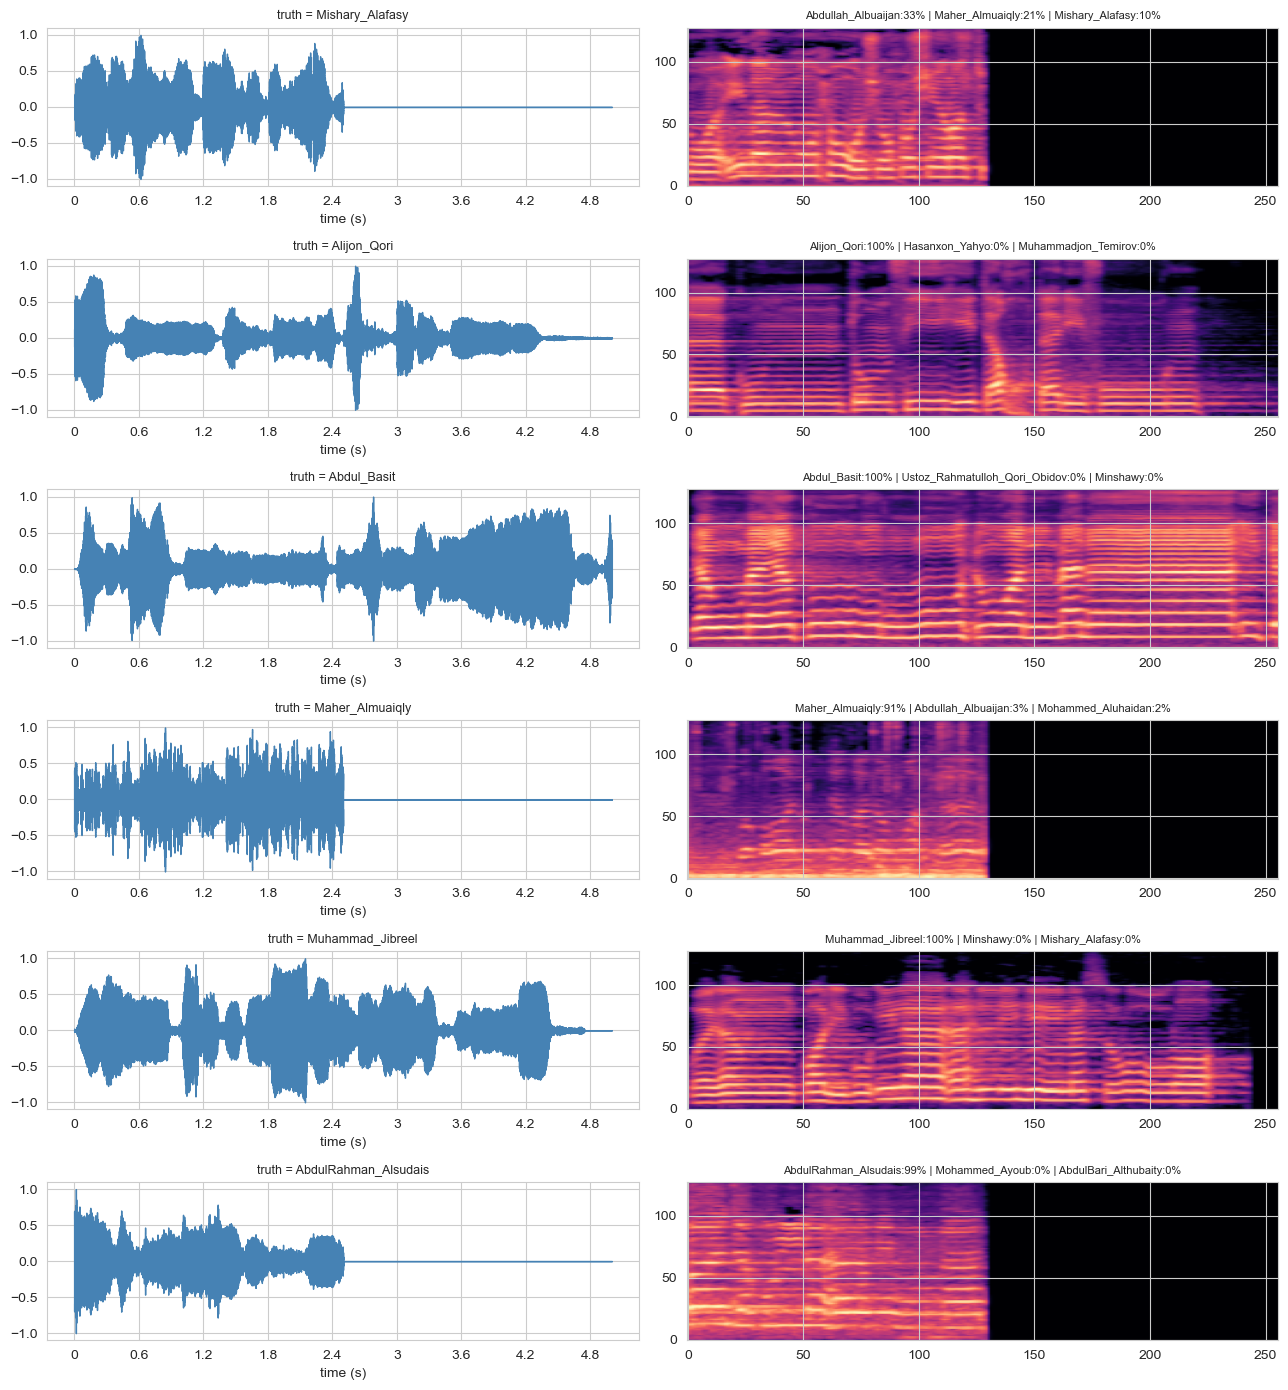

In [14]:
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(test), size=6, replace=False)

fig, axes = plt.subplots(6, 2, figsize=(13, 14))
for row, idx in enumerate(sample_idx):
    path  = test['path'].iloc[idx]
    true  = le.classes_[test['label'].iloc[idx]]
    y, _  = librosa.load(path, sr=SR, mono=True)
    spec  = wav_to_melspec(path)
    with torch.no_grad():
        img = torch.from_numpy(spec).unsqueeze(0).unsqueeze(0).to(device)
        prob = torch.softmax(model(img), dim=1).cpu().numpy().ravel()
    top3_i = prob.argsort()[-3:][::-1]
    guess_str = ' | '.join(f'{le.classes_[i]}:{prob[i]*100:.0f}%' for i in top3_i)

    librosa.display.waveshow(y, sr=SR, ax=axes[row, 0], color='steelblue')
    axes[row, 0].set_title(f'truth = {true}', fontsize=9)
    axes[row, 0].set_xlabel('time (s)')
    axes[row, 1].imshow(spec, origin='lower', aspect='auto', cmap='magma')
    axes[row, 1].set_title(guess_str, fontsize=8)
plt.tight_layout()
plt.show()

## 11. Save model artifacts

In [15]:
MODEL_PATH = Path('qari_cnn.pt')
META_PATH  = Path('qari_cnn_meta.joblib')

torch.save(model.state_dict(), MODEL_PATH)
meta = {
    'label_encoder': le,
    'classes':       list(le.classes_),
    'sr':            SR,
    'n_mels':        N_MELS,
    'img_h':         IMG_H,
    'img_w':         IMG_W,
    'best_val_acc':  best_val,
    'test_acc':      acc,
    'test_top3':     top3,
}
joblib.dump(meta, META_PATH)
print(f'Saved: {MODEL_PATH} ({MODEL_PATH.stat().st_size/1e6:.2f} MB)  &  {META_PATH}')

Saved: qari_cnn.pt (0.42 MB)  &  qari_cnn_meta.joblib


## 12. Classical vs CNN — comparison

In [16]:
sklearn_art = Path('qari_artifacts.joblib')
rows = [
    {'approach': 'CNN on mel-spec (PyTorch)', 'features': '128×256 image',
     'accuracy': acc, 'top3': top3, 'params': sum(p.numel() for p in model.parameters())},
]
if sklearn_art.exists():
    sk = joblib.load(sklearn_art)
    rows.append({
        'approach': f"Classical — {sk.get('model_name', 'sklearn')}",
        'features': '126 MFCC stats',
        'accuracy': float('nan'), 'top3': float('nan'), 'params': 'n/a',
    })
cmp_df = pd.DataFrame(rows)
print(cmp_df.to_string(index=False))
print('\n(sklearn numbers live in quran_qari_classifier_executed.ipynb — CNN accuracy above is what deploys.)')

                      approach       features  accuracy     top3 params
     CNN on mel-spec (PyTorch)  128×256 image  0.977515 0.997752 102018
Classical — LogisticRegression 126 MFCC stats       NaN      NaN    n/a

(sklearn numbers live in quran_qari_classifier_executed.ipynb — CNN accuracy above is what deploys.)


## 13. Model card — deployment summary

In [17]:
from datetime import datetime, timezone

card = f"""
Quran Qari Classifier — Model Card
==================================
Task              : 34-class audio classification (identify the qari from 5s recitation)
Model             : Compact 4-block CNN on mel-spectrograms (PyTorch)
Trainable params  : {sum(p.numel() for p in model.parameters()):,}
Weights file      : qari_cnn.pt ({MODEL_PATH.stat().st_size/1e6:.2f} MB)
Input             : 5-second WAV clip, mono, {SR} Hz
Preprocessing     : mel-spectrogram → power→dB → resize {IMG_H}x{IMG_W} → z-score
Training data     : {len(train):,} clips
Validation data   : {len(val):,} clips
Test data         : {len(test):,} clips
Test accuracy     : {acc*100:.2f} %
Test top-3        : {top3*100:.2f} %
Best val accuracy : {best_val*100:.2f} %
Classes           : {len(le.classes_)} (12 Kaggle base + 13 everyayah scrape + 9 Uzbek)
Trained           : {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')}
Deployment        : Streamlit Cloud — kruzimatov/quran-recitation-recognizer
Intended use      : identify famous qaris from short recitation clips
Limitations       : clean-audio trained; live-mic input may need augmentation retrain
"""
print(card)


Quran Qari Classifier — Model Card
Task              : 34-class audio classification (identify the qari from 5s recitation)
Model             : Compact 4-block CNN on mel-spectrograms (PyTorch)
Trainable params  : 102,018
Weights file      : qari_cnn.pt (0.42 MB)
Input             : 5-second WAV clip, mono, 16000 Hz
Preprocessing     : mel-spectrogram → power→dB → resize 128x256 → z-score
Training data     : 8,298 clips
Validation data   : 1,778 clips
Test data         : 1,779 clips
Test accuracy     : 97.75 %
Test top-3        : 99.78 %
Best val accuracy : 97.86 %
Classes           : 34 (12 Kaggle base + 13 everyayah scrape + 9 Uzbek)
Trained           : 2026-08-24 07:48 UTC
Deployment        : Streamlit Cloud — kruzimatov/quran-recitation-recognizer
Intended use      : identify famous qaris from short recitation clips
Limitations       : clean-audio trained; live-mic input may need augmentation retrain

